In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot
import gc
import helpers.stc_helper as stc_helper
import time
from pycircstat2.hypothesis import rayleigh_test
ss = hf.settings_dict()

In [2]:
for subject_index in ss['subject_idx_list']:

    # loop over each event type
    for event_id in ss['event_id_list']:

        event_name = str(event_id)
        duty_cycle = ss['event_name_list'][event_id - 1]
        subjects_dir = ss['fs_subjects_dir']
        subject = ss['subject_id_list'][subject_index]
        print("loading dataset for subject: ", subject)

        save_dir = Path(ss['hilbert_ref_dir']) / subject / event_name
        save_dir.mkdir(parents=True, exist_ok=True)

        # load hilbert stc data
        hilbert_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-event-{event_name}-z-vol.stc"
        stc = mne.read_source_estimate(hilbert_stc_file)

        morph_fname = op.join(ss['morph_dir'], subject+'-morph.h5')
        morph = mne.read_source_morph(morph_fname)

        morph_stc = morph.apply(stc)

        n_voxels, n_times = morph_stc.data.shape

        delta_r_map = morph_stc.copy().data

        print(f"z min  : {delta_r_map.min():.4f}")
        print(f"z max  : {delta_r_map.max():.4f}")
        print(f"z mean : {delta_r_map.mean():.4f}")
        print(f"Voxels > 0   : {(delta_r_map > 0).sum()} / {n_voxels}")

        morph_stc.save(save_dir / f"{subject}-event-{event_name}-morph-z-vol.stc" , overwrite=True)


loading dataset for subject:  0005_3SJ


  0%|          | Time : 0/1 [00:00<?,       ?it/s]

z min  : -1.1867
z max  : 6.5510
z mean : 0.2559
Voxels > 0   : 1426 / 3031
Overwriting existing file.
Writing STC to disk...
Overwriting existing file.
[done]
loading dataset for subject:  0005_3SJ


  0%|          | Time : 0/1 [00:00<?,       ?it/s]

z min  : -0.7756
z max  : 5.9310
z mean : 0.2511
Voxels > 0   : 1878 / 3031
Overwriting existing file.
Writing STC to disk...
Overwriting existing file.
[done]
loading dataset for subject:  0005_3SJ


...

z min  : -1.7126
z max  : 6.3272
z mean : 0.4437
Voxels > 0   : 1978 / 3031
Overwriting existing file.
Writing STC to disk...
Overwriting existing file.
[done]
loading dataset for subject:  0019_COG


  0%|          | Time : 0/1 [00:00<?,       ?it/s]

z min  : -0.7465
z max  : 7.3147
z mean : 0.6355
Voxels > 0   : 2415 / 3031
Overwriting existing file.
Writing STC to disk...
Overwriting existing file.
[done]
loading dataset for subject:  0019_COG


  0%|          | Time : 0/1 [00:00<?,       ?it/s]

z min  : -0.6617
z max  : 1.4770
z mean : 0.0026
Voxels > 0   : 1244 / 3031
Overwriting existing file.
Writing STC to disk...
Overwriting existing file.
[done]


loading dataset for subject:  0016_XLZ


  0%|          | Time : 0/1 [00:00<?,       ?it/s]

z min  : -0.2190
z max  : 1.5163
z mean : 0.0410
Voxels > 0   : 1385 / 3031
    Reading a source space...
    [done]
    1 source spaces read
Showing: t = 0.000 s, (30.0, 30.0, -60.0) mm, [13, 13, 4] vox, 2050 vertex


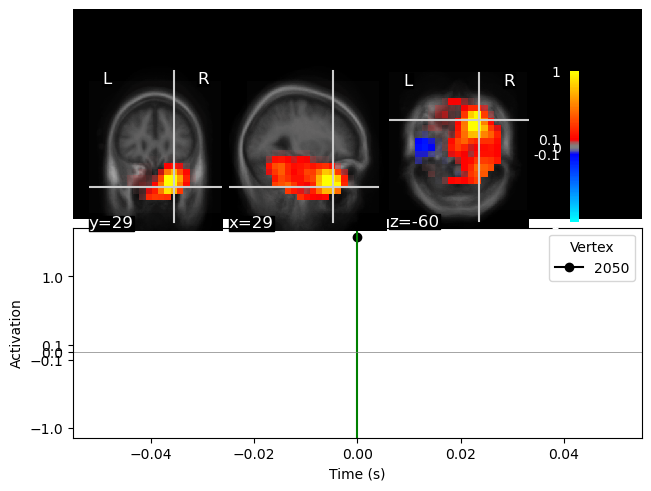

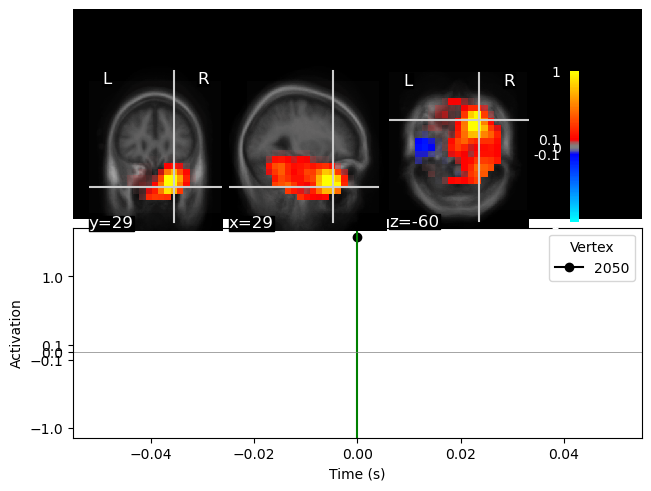

In [3]:

event_id =4
subject_index = 8
event_name = str(event_id)
duty_cycle = ss['event_name_list'][event_id - 1]
subjects_dir = ss['fs_subjects_dir']
subject = ss['subject_id_list'][subject_index]
print("loading dataset for subject: ", subject)

save_dir = Path(ss['hilbert_ref_dir']) / subject / event_name
save_dir.mkdir(parents=True, exist_ok=True)

# load hilbert stc data
hilbert_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-event-{event_name}-z-vol.stc"
stc = mne.read_source_estimate(hilbert_stc_file)

morph_fname = op.join(ss['morph_dir'], subject+'-morph.h5')
morph = mne.read_source_morph(morph_fname)

# morph.affine[2,3] = 170  # Correcting displacement in this dataset
# morph.affine[2,3] = 149  # 10 mm r


morph_stc = morph.apply(stc)

n_voxels, n_times = morph_stc.data.shape

delta_r_map = morph_stc.copy().data

print(f"z min  : {delta_r_map.min():.4f}")
print(f"z max  : {delta_r_map.max():.4f}")
print(f"z mean : {delta_r_map.mean():.4f}")
print(f"Voxels > 0   : {(delta_r_map > 0).sum()} / {n_voxels}")

fsaverage_src_file = Path(ss["fs_subjects_dir"])  / "fsaverage" / "bem" / "fsaverage-vol-10-src.fif"

fsaverage_src = mne.read_source_spaces(str(fsaverage_src_file))

morph_stc.plot(src = fsaverage_src, subject='fsaverage', subjects_dir=subjects_dir,
        clim=dict(kind="value", pos_lims=[0,0.1,1]),)

In [4]:
morph.affine[2,3]

np.float64(170.0)